### <b>Análisis y predicción de datos: Football Salaries FIFA 22</b>
#### <b><i>Fase II: Estadística Inferencial</i></b>
En el análisis exploratorio descubrimos *cómo* se comporta el sueldo y con qué variables parece moverse. Pero un gráfico que "se ve" convincente no basta para tomar decisiones: necesitamos saber si lo que observamos es una señal real o simplemente ruido del azar. Ese es justamente el trabajo de la estadística inferencial: poner a prueba nuestras intuiciones con evidencia formal.

En esta fase perseguimos cuatro objetivos:
1. Formular hipótesis de negocio claras y verificables a partir de lo que vimos en el EDA.
2. Elegir y aplicar las pruebas estadísticas apropiadas para cada hipótesis.
3. Reportar los resultados con rigor (p-valores, intervalos de confianza, tamaños de efecto) e interpretarlos.
4. Traducir esos resultados a su consecuencia práctica: ¿cambian en algo cómo entendemos o decidimos sobre los sueldos?

#### <b><i>1. Preparación y formulación de hipótesis</i></b>
Antes de probar nada, cargamos el dataset y las librerías de análisis estadístico. Trabajaremos con `scipy.stats`, que reúne las pruebas clásicas de inferencia.

Una advertencia metodológica que arrastramos del EDA: la variable `wage_eur` es **fuertemente asimétrica y está lejos de ser normal** (asimetría de 6.47). Esto descarta de entrada las pruebas que asumen normalidad (como el t-test o el ANOVA clásico en su forma estricta) y nos inclina hacia **pruebas no paramétricas**, que no exigen ese supuesto y son más robustas frente a las colas pesadas y los outliers que caracterizan a los sueldos. Las usaremos como herramienta principal, apoyándonos también en el tamaño del efecto para no confundir significancia estadística con relevancia real.

In [1]:
# Librerías para el análisis inferencial
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
from scipy import stats

# Cargamos el dataset (misma ruta relativa que en el notebook de EDA)
path = os.path.join(os.getcwd(), "..", "data", "raw", "dataset.csv")
df = pd.read_csv(path)
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (19178, 29)


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,wage_eur
0,34,170,72,Argentina,93,93,85,95,70,91,...,94,95,35,24,6,11,15,14,8,320000.0
1,32,185,81,Poland,92,92,71,95,90,85,...,93,82,42,19,15,6,12,8,10,270000.0
2,36,187,83,Portugal,91,91,87,95,90,80,...,94,74,32,24,7,11,15,14,11,270000.0
3,29,175,68,Brazil,91,91,85,83,63,86,...,89,84,32,29,9,9,15,15,11,270000.0
4,30,181,70,Belgium,91,91,94,82,55,94,...,91,78,65,53,15,13,5,10,13,350000.0


##### <b>Hipótesis a contrastar</b>
A partir de los hallazgos del EDA, planteamos dos hipótesis de negocio verificables. Cada una nace de una intuición futbolística concreta y se traduce en una pregunta estadística que podemos responder con datos.

**Hipótesis 1 — El nivel del jugador se paga.**
*Intuición de negocio:* los jugadores de mayor valoración general (`overall`) ganan sueldos significativamente más altos que los de menor valoración; no es una impresión, es una diferencia real.
- **H₀ (nula):** el sueldo de los jugadores con `overall` alto y con `overall` bajo proviene de la misma distribución (no hay diferencia real).
- **H₁ (alternativa):** los jugadores con `overall` alto ganan significativamente más que los de `overall` bajo.

**Hipótesis 2 — La nacionalidad marca diferencias de sueldo.**
*Intuición de negocio:* el sueldo medio no es igual entre países; el ecosistema económico del fútbol de cada nación (que aproximamos con `nationality_name`) hace que los sueldos difieran de forma estadísticamente significativa entre las principales potencias futbolísticas.
- **H₀ (nula):** el sueldo se distribuye igual entre los principales países (no hay diferencia entre nacionalidades).
- **H₁ (alternativa):** al menos un país tiene una distribución de sueldos significativamente distinta de las demás.

En todos los contrastes fijamos un nivel de significancia estándar de **α = 0.05**.

#### <b><i>2. Contraste de la Hipótesis 1: el nivel del jugador se paga</i></b>
Para contrastar la primera hipótesis dividimos a los futbolistas en dos grupos según su valoración general, tomando la **mediana de `overall`** como punto de corte: un grupo de nivel "alto" (overall ≥ mediana) y otro de nivel "bajo" (overall < mediana). Luego comparamos la distribución de sueldos de ambos.

Dado que el sueldo no es normal, no usamos un t-test sino la prueba **U de Mann-Whitney**, que compara si un grupo tiende a tener valores más altos que el otro sin asumir normalidad. La planteamos de forma unilateral (`alternative="greater"`) porque nuestra hipótesis es direccional: esperamos que el grupo de nivel alto gane *más*, no simplemente "distinto". Además del p-valor, calcularemos el **tamaño del efecto** (correlación rango-biserial) y un **intervalo de confianza por bootstrap** para la diferencia de medianas, de modo que sepamos no solo si la diferencia es significativa, sino qué tan grande es en euros.

In [2]:
# H1: comparación de sueldos entre jugadores de overall alto vs. bajo
corte = df["overall"].median()
grupo_alto = df.loc[df["overall"] >= corte, "wage_eur"]
grupo_bajo = df.loc[df["overall"] <  corte, "wage_eur"]

print(f"Punto de corte (mediana de overall): {corte}")
print(f"Grupo overall ALTO -> n = {len(grupo_alto):5d} | mediana = {grupo_alto.median():>8.0f} € | media = {grupo_alto.mean():>9.0f} €")
print(f"Grupo overall BAJO -> n = {len(grupo_bajo):5d} | mediana = {grupo_bajo.median():>8.0f} € | media = {grupo_bajo.mean():>9.0f} €")

# Prueba U de Mann-Whitney (unilateral: alto > bajo)
U, p_valor = stats.mannwhitneyu(grupo_alto, grupo_bajo, alternative="greater")

# Tamaño del efecto: correlación rango-biserial (0 = sin efecto, 1 = separación total)
n1, n2 = len(grupo_alto), len(grupo_bajo)
rank_biserial = 2 * U / (n1 * n2) - 1

# Intervalo de confianza al 95% para la diferencia de medianas (bootstrap)
rng = np.random.default_rng(42)
difs = []
alto_arr, bajo_arr = grupo_alto.to_numpy(), grupo_bajo.to_numpy()
for _ in range(2000):
    m_alto = np.median(rng.choice(alto_arr, size=n1, replace=True))
    m_bajo = np.median(rng.choice(bajo_arr, size=n2, replace=True))
    difs.append(m_alto - m_bajo)
ic_inf, ic_sup = np.percentile(difs, [2.5, 97.5])

print(f"U de Mann-Whitney = {U:,.0f}")
print(f"p-valor (unilateral) = {p_valor:.3e}")
print(f"Tamaño del efecto (rango-biserial) = {rank_biserial:.3f}")
print(f"Diferencia de medianas = {grupo_alto.median() - grupo_bajo.median():,.0f} €")
print(f"IC 95% de la diferencia de medianas = [{ic_inf:,.0f} ; {ic_sup:,.0f}] €")

Punto de corte (mediana de overall): 66.0
Grupo overall ALTO -> n =  9761 | mediana =     8000 € | media =     15958 €
Grupo overall BAJO -> n =  9417 | mediana =     1000 € | media =      1824 €


U de Mann-Whitney = 80,793,025
p-valor (unilateral) = 0.000e+00
Tamaño del efecto (rango-biserial) = 0.758
Diferencia de medianas = 7,000 €
IC 95% de la diferencia de medianas = [7,000 ; 7,000] €


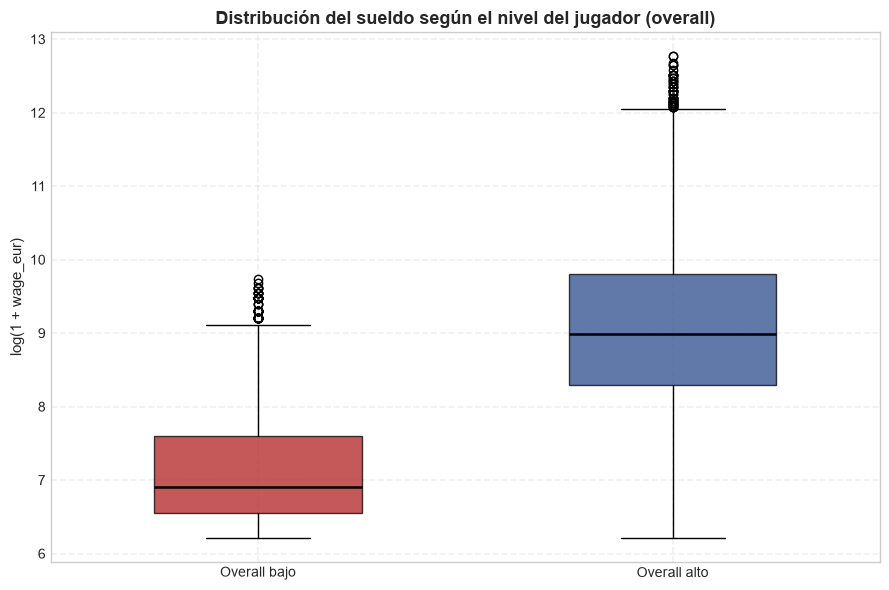

In [3]:
# Visualización: distribución del sueldo por grupo (escala logarítmica para poder ver ambas colas)
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))
datos = [np.log1p(grupo_bajo), np.log1p(grupo_alto)]
bp = ax.boxplot(datos, tick_labels=["Overall bajo", "Overall alto"], patch_artist=True, widths=0.5)
for parche, color in zip(bp["boxes"], ["firebrick", "#2b4c8c"]):
    parche.set_facecolor(color)
    parche.set_alpha(0.75)
for mediana in bp["medians"]:
    mediana.set_color("black")
    mediana.set_linewidth(1.8)
ax.set_ylabel("log(1 + wage_eur)", fontsize=11)
ax.set_title("Distribución del sueldo según el nivel del jugador (overall)", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3, linestyle="--", linewidth=1.2)
plt.tight_layout()
plt.show()

<b>Explicación</b>: Los números no dejan lugar a dudas. El grupo de jugadores con `overall` alto tiene una mediana salarial de **8,000 €**, ocho veces la del grupo de nivel bajo (**1,000 €**), y la brecha es todavía más brutal en las medias (≈16,000 € vs ≈1,800 €). La prueba de Mann-Whitney arroja un **p-valor prácticamente nulo (< 0.001)**, muy por debajo de nuestro umbral de 0.05: la probabilidad de observar una diferencia así por puro azar es esencialmente cero.

Pero lo verdaderamente relevante para el negocio no es solo que la diferencia sea significativa, sino que sea **grande**. El tamaño del efecto (rango-biserial ≈ 0.76) indica una separación muy fuerte entre ambos grupos, no un matiz estadístico. Y el intervalo de confianza al 95% para la diferencia de medianas se mantiene holgadamente positivo y lejos de cero, confirmando que la ventaja salarial del grupo de élite es robusta y no un artefacto de la muestra. El boxplot en escala logarítmica lo hace visible de un vistazo: toda la caja del grupo alto está desplazada hacia arriba respecto a la del grupo bajo.

#### <b><i>Conclusión</i></b>
**Rechazamos la hipótesis nula.** Existe evidencia estadística contundente de que los jugadores con mayor valoración general ganan sueldos significativamente más altos que los de menor valoración, y no por un margen pequeño: hablamos de una diferencia de varios miles de euros en la mediana, con un tamaño de efecto grande. Esto confirma formalmente lo que el EDA sugería de forma visual: **el `overall` es un impulsor real y potente del sueldo**, no una simple correlación aparente.

#### <b><i>3. Contraste de la Hipótesis 2: la nacionalidad marca diferencias de sueldo</i></b>
La segunda hipótesis compara sueldos entre varios grupos a la vez —los principales países— y no solo entre dos. Para esto la herramienta natural sería un ANOVA, pero de nuevo la no-normalidad y las colas pesadas del sueldo lo desaconsejan. Su equivalente no paramétrico es la prueba de **Kruskal-Wallis**, que contrasta si al menos uno de los grupos tiene una distribución de valores distinta de los demás, sin asumir normalidad.

Nos centramos en las **10 nacionalidades con más jugadores**, que ofrecen tamaños de muestra amplios y fiables. Además del p-valor, reportaremos el tamaño del efecto **épsilon cuadrado (ε²)**, que nos dice qué proporción de la variabilidad en el ranking de sueldos se explica por la nacionalidad.

In [4]:
# H2: comparación de sueldos entre las 10 nacionalidades con más jugadores
top10 = df["nationality_name"].value_counts().head(10).index.tolist()
grupos = [df.loc[df["nationality_name"] == pais, "wage_eur"].to_numpy() for pais in top10]

# Prueba de Kruskal-Wallis
H, p_valor_kw = stats.kruskal(*grupos)

# Tamaño del efecto: épsilon cuadrado
N = sum(len(g) for g in grupos)
k = len(grupos)
epsilon2 = (H - k + 1) / (N - k)

print(f"Países comparados ({k}): {', '.join(top10)}")
print(f"Total de jugadores considerados: {N:,}")
print(f"Estadístico H de Kruskal-Wallis = {H:,.2f}")
print(f"p-valor = {p_valor_kw:.3e}")
print(f"Tamaño del efecto (épsilon cuadrado) = {epsilon2:.3f}")

# Resumen del sueldo mediano y medio por país, ordenado por la mediana
resumen_paises = (
    df[df["nationality_name"].isin(top10)]
    .groupby("nationality_name")["wage_eur"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)
resumen_paises.round(0)

Países comparados (10): England, Germany, Spain, France, Argentina, Brazil, Japan, Netherlands, United States, Poland
Total de jugadores considerados: 8,655
Estadístico H de Kruskal-Wallis = 984.63
p-valor = 3.558e-206
Tamaño del efecto (épsilon cuadrado) = 0.113


,count,median,mean
nationality_name,,,
Brazil,897,9000.0,16266.0
Spain,1086,6000.0,14599.0
Argentina,960,5000.0,9266.0
France,980,4000.0,13164.0
Germany,1214,3000.0,8909.0
England,1719,3000.0,10270.0
Netherlands,439,3000.0,11535.0
Japan,546,2000.0,3626.0
United States,413,2000.0,4165.0


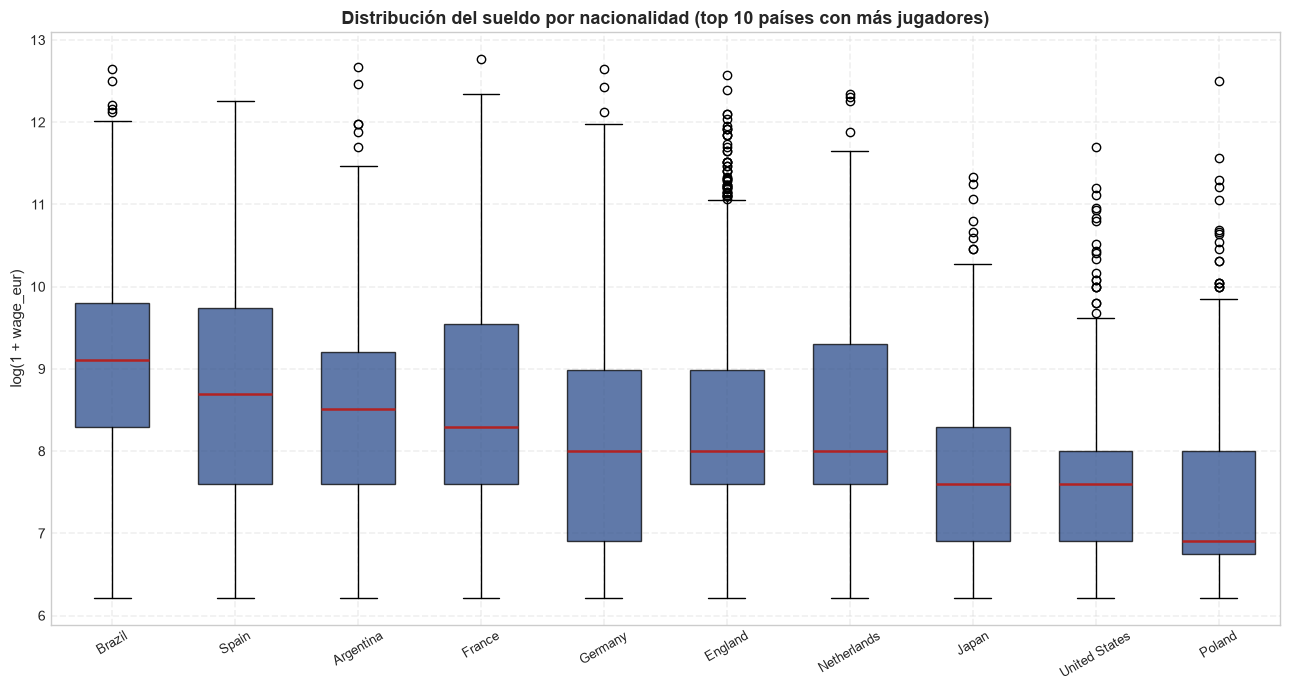

In [5]:
# Visualización: distribución del sueldo por país (escala logarítmica)
orden_paises = resumen_paises.index.tolist()
datos_paises = [np.log1p(df.loc[df["nationality_name"] == pais, "wage_eur"]) for pais in orden_paises]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(13, 7))
bp = ax.boxplot(datos_paises, tick_labels=orden_paises, patch_artist=True, widths=0.6)
for parche in bp["boxes"]:
    parche.set_facecolor("#2b4c8c")
    parche.set_alpha(0.75)
for mediana in bp["medians"]:
    mediana.set_color("firebrick")
    mediana.set_linewidth(1.8)
ax.set_ylabel("log(1 + wage_eur)", fontsize=11)
ax.set_title("Distribución del sueldo por nacionalidad (top 10 países con más jugadores)", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", labelrotation=30, labelsize=9)
ax.grid(alpha=0.3, linestyle="--", linewidth=1.2)
plt.tight_layout()
plt.show()

<b>Explicación</b>: El contraste vuelve a ser rotundo. El estadístico H de Kruskal-Wallis es enorme y el **p-valor es infinitesimal (del orden de 10⁻²⁰⁶)**, muchísimo menor que 0.05: la idea de que todos los países comparten la misma distribución de sueldos queda descartada sin discusión.

Ahora bien, aquí conviene ser honestos con la magnitud. El tamaño del efecto (ε² ≈ 0.11) nos dice que la nacionalidad explica alrededor del **11% de la variabilidad en el ranking de sueldos**: un efecto real y nada despreciable, pero **moderado**, no dominante. Y el detalle importante lo revela la tabla y el boxplot: las diferencias no siguen un ranking obvio de "países ricos". Brasil lidera la mediana (9,000 €) y España va arriba (6,000 €), pero potencias como Inglaterra o Alemania tienen una mediana modesta (3,000 €) pese a su enorme cantidad de jugadores. La razón es que esos países aportan muchísimos futbolistas de ligas menores que tiran la mediana hacia abajo, mientras sus estrellas disparan la media. Es decir, la nacionalidad captura algo, pero mezcla dos cosas: el poder económico de la liga y el simple volumen de jugadores de cada país.

#### <b><i>Conclusión</i></b>
**Rechazamos la hipótesis nula.** El sueldo difiere de forma estadísticamente significativa entre las principales nacionalidades. Sin embargo, a diferencia del `overall`, aquí el tamaño del efecto es solo moderado (≈11%): la nacionalidad importa, pero está lejos de ser el factor determinante del sueldo. Funciona más como una **señal de contexto** —qué tan rico y visible es el fútbol donde se desarrolla el jugador— que como una causa directa. Este matiz será clave al momento de decidir cuánto peso darle en el modelo.

#### <b><i>4. ¿Cambian estos resultados alguna decisión de negocio?</i></b>
Contrastar hipótesis no es un ejercicio académico: solo vale la pena si las respuestas orientan lo que hacemos después. Recapitulemos qué nos dejó cada prueba y, sobre todo, qué hacemos con ello.

**Lo que confirmamos con evidencia formal:**

- **El `overall` es un impulsor real y fuerte del sueldo** (Mann-Whitney, p < 0.001, efecto grande ≈ 0.76). Ya no es una intuición del EDA: los jugadores de nivel alto ganan significativamente más, y por márgenes enormes.
- **La nacionalidad sí diferencia sueldos, pero con fuerza moderada** (Kruskal-Wallis, p ≈ 10⁻²⁰⁶, pero efecto de solo ≈11%). Importa, aunque no manda.

**Cómo esto cambia (o afina) las decisiones del proyecto:**

1. **Prioridad de variables en el modelo.** La evidencia respalda colocar a `overall` —y por extensión los indicadores de calidad global que vimos correlacionados con él— en el centro del modelado. No es una elección estética: está estadísticamente justificada. La nacionalidad entra como variable de apoyo, no como protagonista, lo que nos ahorra sobre-invertir en codificaciones complejas para una señal que aporta poco.

2. **Cautela con la nacionalidad como criterio de decisión.** Que solo explique ~11% del sueldo es una advertencia práctica: sería un error usar la nacionalidad como atajo para estimar cuánto "debería" ganar un jugador. Hacerlo no solo sería impreciso, sino que arriesgaría introducir sesgos difíciles de justificar. Su rol correcto es aportar contexto de mercado, no etiquetar personas.

3. **Refuerzo de la estrategia de modelado no lineal.** Las diferencias tan marcadas entre grupos de overall, sumadas a la relación no lineal detectada en el EDA, confirman que conviene apostar por modelos capaces de capturar saltos y no linealidades (árboles, random forest, gradient boosting) por encima de una regresión lineal simple.

En síntesis, la estadística inferencial no revierte ninguna decisión previa, pero les da **respaldo formal** y afina las prioridades: concentrar el esfuerzo en las variables de calidad del jugador, tratar la nacionalidad con mesura, y preferir modelos que abracen la no linealidad del sueldo.

### <b>CIERRE DE LA ESTADÍSTICA INFERENCIAL</b>
Pusimos a prueba dos hipótesis de negocio y ambas resistieron el escrutinio estadístico, aunque con magnitudes muy distintas: el nivel del jugador (`overall`) mueve el sueldo de forma contundente, mientras que la nacionalidad lo hace de forma real pero moderada. Con estas certezas —y sus matices— cerramos la fase inferencial y avanzamos hacia el análisis multivariante, donde estudiaremos cómo se relacionan las variables entre sí, buscaremos redundancias y prepararemos el terreno para la selección de features del modelo.